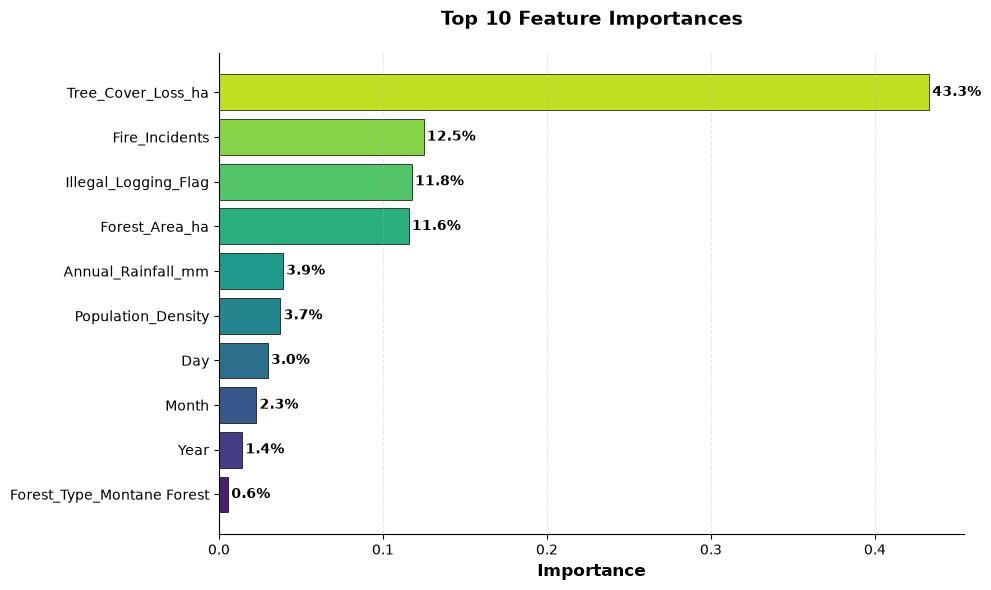

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load feature importance
importance = pd.read_csv("../src/feature_importance.csv")

# Sort by importance (already sorted, but let's be safe)
importance = importance.sort_values("Importance", ascending=True)

# Take top 10 for readability
top_10 = importance.tail(10)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_10["Feature"], 
    top_10["Importance"], 
    color=sns.color_palette("viridis", 10),
    edgecolor="black",
    linewidth=0.5
)

# Add percentage labels
for bar, value in zip(bars, top_10["Importance"]):
    ax.text(
        value + 0.002, 
        bar.get_y() + bar.get_height()/2, 
        f"{value*100:.1f}%", 
        va="center", 
        ha="left", 
        fontsize=10,
        fontweight="bold"
    )

# Styling
ax.set_xlabel("Importance", fontsize=12, fontweight="bold")
ax.set_title("Top 10 Feature Importances", fontsize=14, fontweight="bold", pad=20)
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save
plt.savefig("../visuals/visualization_outputs/11_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()